# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [9]:
df = pd.read_csv("C:/Users/juhan/OneDrive/Área de Trabalho/dev/Ciência de dados EBAC/MOD 18/ATIVIDADE 18/ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [10]:
#Seu código aqui
df.info()
#df.describe()
cols = ['Valor_Condominio', 'N_Suites', 'N_Vagas']

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].mean())
(((df == 0) | df.isnull()).sum() / len(df)) * 100

#preferi colocar a média pois as colunas são importantes para analise e estavam com valores "0".

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


Valor_Aluguel       0.0
Valor_Condominio    0.0
Metragem            0.0
N_Quartos           0.0
N_banheiros         0.0
N_Suites            0.0
N_Vagas             0.0
dtype: float64

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

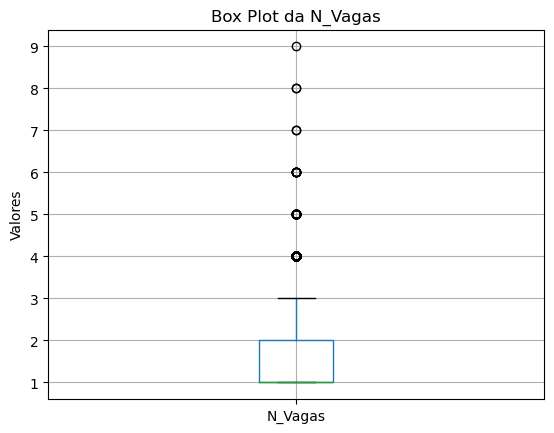

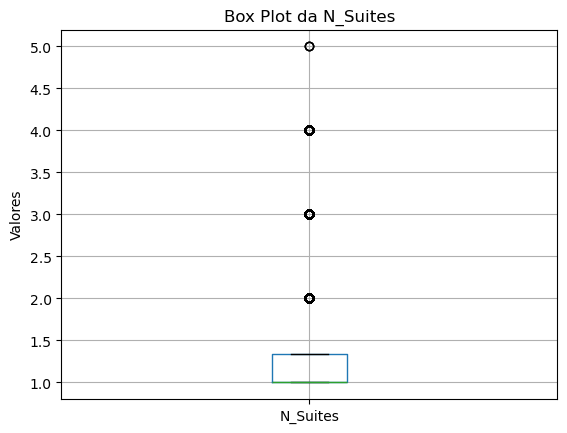

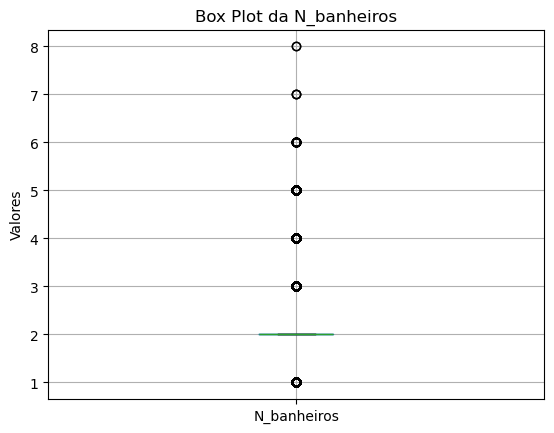

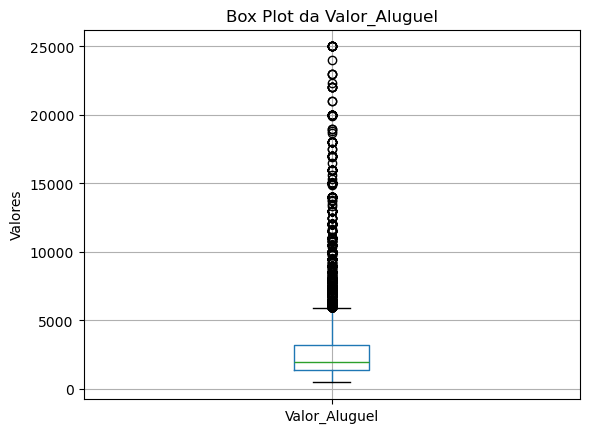

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.0,7203.000000,7203.000000
mean,2966.596140,799.022964,82.183951,2.296682,2.0,1.140914,1.512981
std,2948.720385,456.899347,41.343357,0.813913,0.0,0.347956,0.778382
min,480.000000,1.000000,30.000000,1.000000,2.0,1.000000,1.000000
25%,1350.000000,458.000000,52.000000,2.000000,2.0,1.000000,1.000000
50%,2000.000000,680.000000,67.000000,2.000000,2.0,1.000000,1.000000
75%,3200.000000,980.000000,100.000000,3.000000,2.0,1.000000,2.000000
max,25000.000000,1763.000000,172.000000,4.000000,2.0,2.000000,4.000000


In [11]:
#Seu código aqui

#B)
df.boxplot(column='N_Vagas')
plt.title('Box Plot da N_Vagas')
plt.ylabel('Valores')
plt.show()

df.boxplot(column='N_Suites')
plt.title('Box Plot da N_Suites')
plt.ylabel('Valores')
plt.show()

df.boxplot(column='N_banheiros')
plt.title('Box Plot da N_banheiros')
plt.ylabel('Valores')
plt.show()

df.boxplot(column='Valor_Aluguel')
plt.title('Box Plot da Valor_Aluguel')
plt.ylabel('Valores')
plt.show()

# Eu tive que fazer uma pesquisa de mercado por que pra mim alguns valores estavam desconexos, isso me deixou com dúvidas, de toda forma, só encontrei apto de no maximo 500m, sem contar que não encontrei apto com 10 quartos, levando em consideração que eu tenho que pensar na materialidade das informações, eu vou retirar outliers de praticamente todas as metricas.
# Até porque não é informado na atividade qual o público alvo, levando em conta o IDH e PIB per capta br, os apartamentos com valores absurdos em todos os aspectos são menoria, levando em consideração o fato que a construção de studios está em alta justamente por questão de espaço
def tratar_outliers_capping(df, coluna):

  Q1 = df[coluna].quantile(0.25)

  Q3 = df[coluna].quantile(0.75)

  IQR = Q3 - Q1



  limite_inf = Q1 - 1.5 * IQR

  limite_sup = Q3 + 1.5 * IQR



  df[coluna] = np.where(

    df[coluna] > limite_sup, limite_sup,

    np.where(df[coluna] < limite_inf, limite_inf, df[coluna])

  )

  return df

colunas = ['Metragem', 'N_Quartos', 'Valor_Condominio', 'N_banheiros', 'N_Suites', 'N_Vagas']

for col in colunas:

  df = tratar_outliers_capping(df, col)

col_discretas = ['N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']

for col in col_discretas:

  df[col] = df[col].round().astype(int)

#Analises bivariadas

fig = px.scatter(df, x='Metragem', y='Valor_Aluguel', opacity=0.6)

fig.update_layout(

  title='Relação entre Metragem e Aluguel',

  xaxis_title='Metragem',

  yaxis_title='Aluguel'
    )

fig.show()


fig = px.scatter(df, x='N_Quartos', y='Valor_Aluguel', opacity=0.6)

fig.update_layout(

  title='Relação entre N_Quartos e Aluguel',

  xaxis_title='N_Quartos',

  yaxis_title='Aluguel'
    )

fig.show()

fig = px.scatter(df, x='N_Suites', y='Valor_Aluguel', opacity=0.6)

fig.update_layout(

  title='Relação entre N_Suites e Aluguel',

  xaxis_title='N_Suites',

  yaxis_title='Aluguel'
    )

fig.show()


fig = px.scatter(df, x='Valor_Condominio', y='Valor_Aluguel', opacity=0.6)

fig.update_layout(

  title='Relação entre Valor_Condominio e Aluguel',

  xaxis_title='Valor_Condominio',

  yaxis_title='Aluguel'
    )

fig.show()

fig = px.scatter(df, x='N_banheiros', y='Valor_Aluguel', opacity=0.6)

fig.update_layout(

  title='Relação entre N_banheiros e Aluguel',

  xaxis_title='N_banheiros',

  yaxis_title='Aluguel'
    )

fig.show()



df.describe()


# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




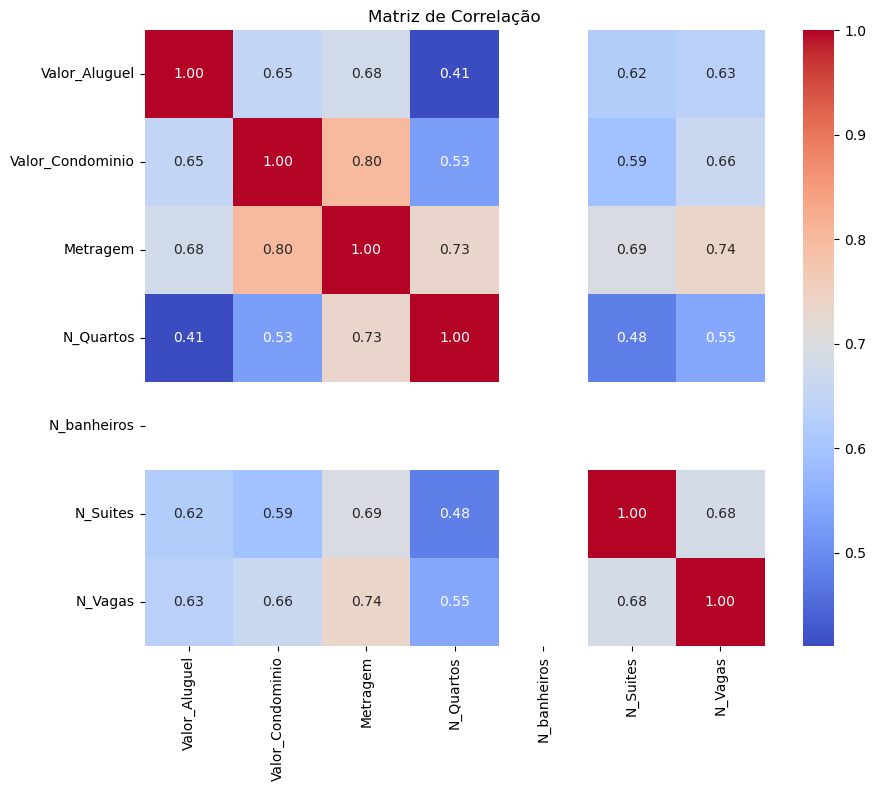

In [12]:
#Seu código aqui
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [13]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [14]:
# Seu código aqui
# Divisão treino e teste (70% treino / 30% teste)
X_train, X_test, y_train, y_test = train_test_split(
 X, y,
 test_size=0.3,
 random_state=42
)

# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [15]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.
metragem_counts = df['Metragem'].value_counts()
plt.figure(figsize=(8, 6))
metragem_counts.plot(kind='bar', color=['blue', 'orange'])
#plt.show()
print((df['Metragem'].value_counts(normalize=True) * 100))
#tentei aplicar o smote, mas como não tem vizinhos não funcionou.

Metragem
172.0    9.121200
50.0     5.886436
60.0     4.678606
70.0     4.359295
65.0     3.429127
           ...   
108.0    0.041649
129.0    0.041649
166.0    0.041649
152.0    0.027766
121.0    0.013883
Name: proportion, Length: 143, dtype: float64


In [16]:
#Crie seu modelo aqui, usando LinearRegression e as bases de treino.
regressao_valor_aluguel = LinearRegression()

regressao_valor_aluguel.fit(X,y)

LinearRegression()

B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [17]:
#Seu código Aqui
intercepto = regressao_valor_aluguel.intercept_

coeficiente = regressao_valor_aluguel.coef_[0]

print(f"Intercepto: {intercepto}")

print(f"Coeficiente: {coeficiente}")

Intercepto: -938.921807075712
Coeficiente: 47.35836856616096


Nossa equação seria:  Valor_Aluguel = 47*Metragem -939 

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [18]:
#Seu código aqui
regressao_valor_aluguel.score(X,y)

0.4562563829239833

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

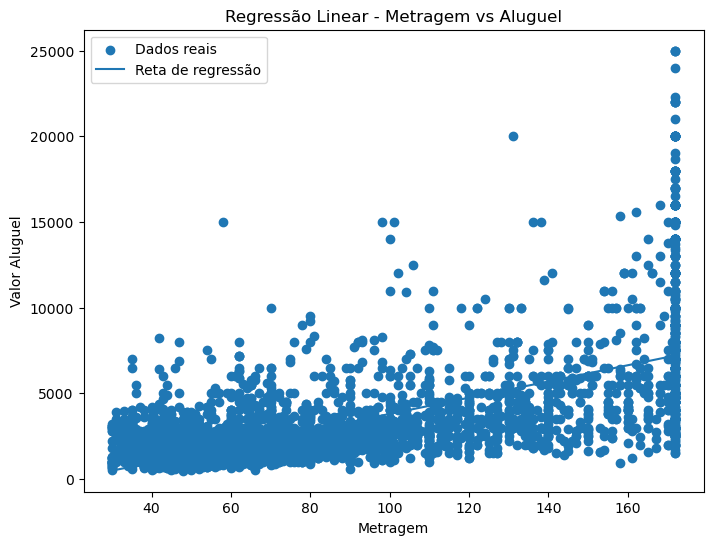

In [22]:
# Seu código aqui
# Plotar os dados originais
# Ordenar os dados pela metragem
X_ordenado = X.sort_values(by='Metragem')
y_pred = regressao_valor_aluguel.predict(X_ordenado)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X, y, label='Dados reais')
plt.plot(X_ordenado, y_pred, label='Reta de regressão')


plt.xlabel('Metragem')
plt.ylabel('Valor Aluguel')
plt.title('Regressão Linear - Metragem vs Aluguel')
plt.legend()

plt.show()

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [25]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

In [26]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = regressao_valor_aluguel.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = regressao_valor_aluguel.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.46545210609170085


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

Escreva sua resposta aqui.

R teste = 0.4562563829239833 - R² = 0.46545210609170085

Os Rs estão bem próximos o que traz um cenário ideal, eles estão abaixo de 0.5 que pelo que pesquisei significa que o modelo está underfitting, no caso ele está confiável porém explica pouco, vi que talvez fosse interessante inserir mais dados, porém como é uma base pequena e controlada acho que está dentro do esperado.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [36]:
#seu código aqui

X = df[['Metragem', 'Valor_Condominio', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas' ]]  # Variável independente (características)
y = df['Valor_Aluguel']  # Variável dependente (rótulo)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [37]:
#seu código aqui
Linear_multiplo = LinearRegression()
Linear_multiplo.fit(X_train, y_train)



LinearRegression()

C) Traga o valor do R quadrado e avalie o valor encontrado.

In [39]:
#seu código aqui

intercepto = Linear_multiplo.intercept_

coeficiente = Linear_multiplo.coef_[0]

print(f"Intercepto: {intercepto}")

print(f"Coeficiente: {coeficiente}")

Linear_multiplo.score(X,y)

#Valor_Aluguel = 24*Metragem -1772 

Intercepto: -1772.720452469333
Coeficiente: 24.14029762410668


0.5530068571213642

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [43]:
#seu código aqui
regressao_valor_aluguel.fit(X_train, y_train)
previsoes = regressao_valor_aluguel.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = regressao_valor_aluguel.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.5423619886943343


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

Digite sua resposta aqui

O Modelo de Regressão Linear Multipla me parece melhor, está acima de 0.5, tanto o teste quanto a previsão, o que indica maior acurácia do que no modelo linear anterior, com mais variáveis o modelo pode usar a correlação para fazer a curva da equação da reta de forma mais assertiva.